# Notebook Guide to Frequency Processing

### Orbit Correction
First, lets correct for orbital motion! This can be called from the orbit_correction.py file.

In [1]:
from frequency_analysis.orbit_correction import *

In [2]:
target_id = '799'           # Barycenter code for Uranus
observer_id = '@tess'          
flux_data_file = '/scratch11/ktp9/TESS_SolarSystem/Uranus/s44_cam1_ccd4/results_bps40_pps10/lc_Uranus_s44_cam1_ccd4.txt'

In [3]:
times, raw_flux, corrected_lightcurve = run_orbit_correction(target_id, observer_id, flux_data_file)

Parsing Light Curve
Getting ephemeris
Correcting Light curve


We can see that you only need a few lines of code for this, and the light curve file from the _tess-solarsystem_ code. Lets see how the correction compares to the raw flux.

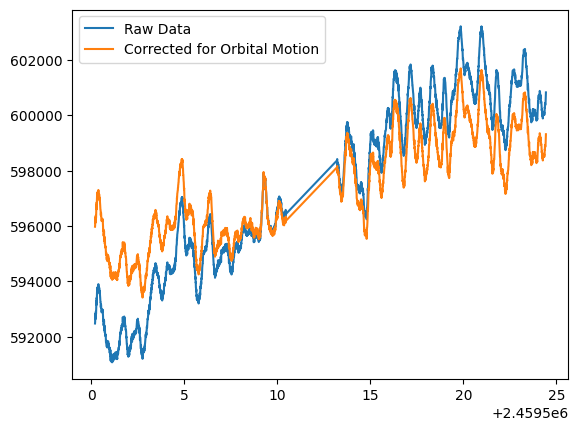

In [4]:
import matplotlib.pyplot as plt 

plt.plot(times, raw_flux, label="Raw Data")
plt.plot(times, corrected_lightcurve, label="Corrected for Orbital Motion")
plt.legend()
plt.show()

### Periodogram Analysis

Next, lets look at the peak periodicities in this light curve. 

In [5]:
from frequency_analysis.frequency_processing import *

In [6]:
frequency, power, false_alarm_array = make_periodogram(times, corrected_lightcurve, 0.05, 3, 10, 1)

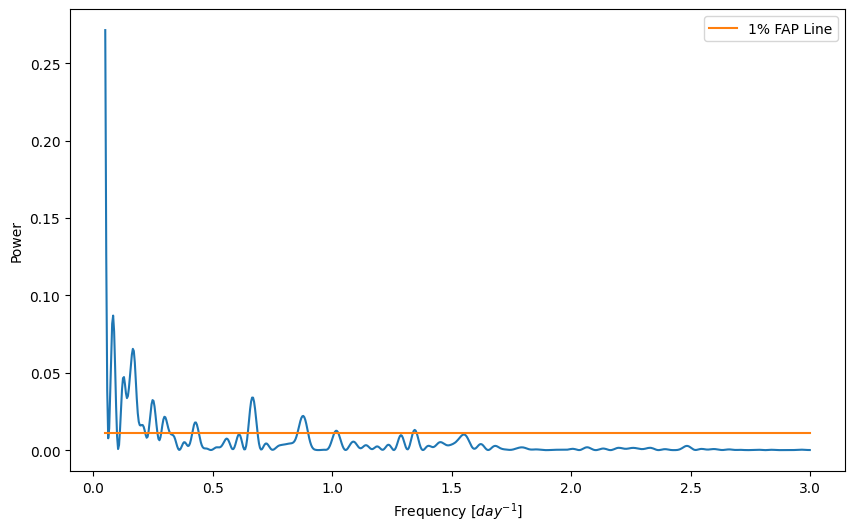

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(frequency, power)
plt.plot(frequency, false_alarm_array, label="1% FAP Line")
plt.legend()
plt.xlabel(r"Frequency $[day^{-1}]$")
plt.ylabel("Power")
plt.show()

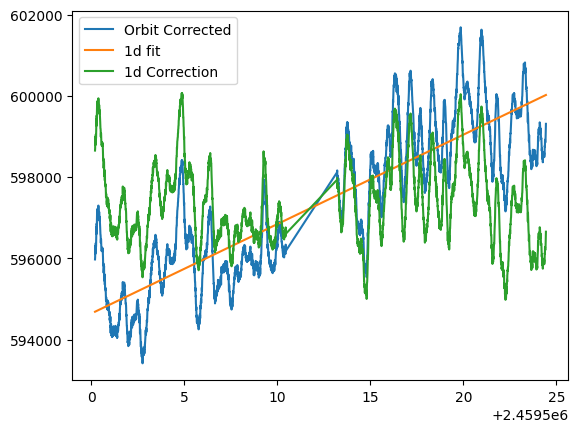

In [8]:
linear_fit, line, detrended = linear_detrend(times, corrected_lightcurve)

plt.plot(times, corrected_lightcurve, label="Orbit Corrected")
plt.plot(times, line, label="1d fit")
plt.plot(times, detrended, label="1d Correction")
plt.legend()
plt.show()

In [9]:
frequency_dt, power_dt, false_alarm_array_dt = make_periodogram(times, detrended, 0.05, 3, 10, 1)

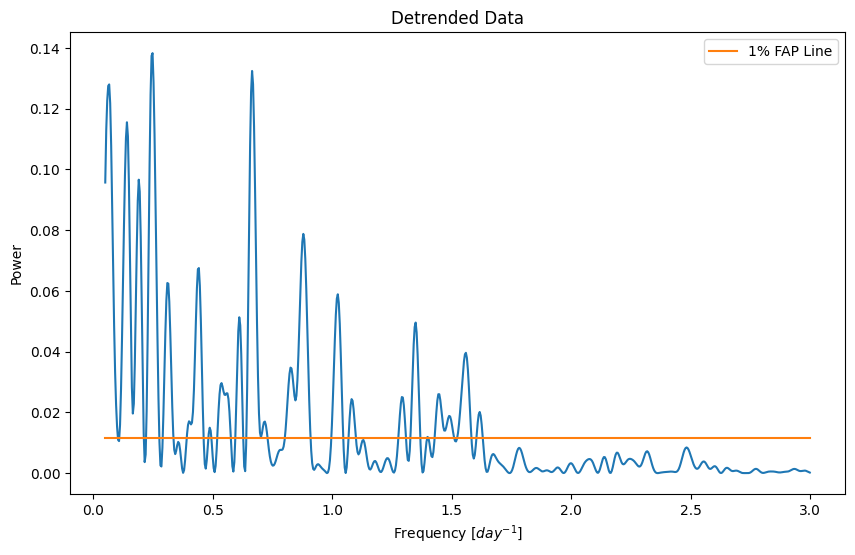

In [10]:
plt.figure(figsize=(10, 6))
plt.title("Detrended Data")
plt.plot(frequency_dt, power_dt)
plt.plot(frequency_dt, false_alarm_array_dt, label="1% FAP Line")
plt.legend()
plt.xlabel(r"Frequency $[day^{-1}]$")
plt.ylabel("Power")
plt.show()

In [11]:
peaks = get_peak_frequencies(frequency_dt, power_dt, false_alarm_array_dt)

### MCMC sampling

Great! So we have our detrended periodogram and our peak frequencies. Now, lets convert these to latitudes.

In [12]:
from frequency_analysis.mcmc import *
from frequency_analysis.wind_equations import *

In [13]:
radius = 25559000 # meters
period = 17.247864 # hours
uranus_min_freq = find_minimum_frequency(sromovsky2012_odd, frequency_wind_speed(radius, period))

Minimum f with at least one intersection: 1.360531


/home/ktp9/anaconda3/envs/TESSNeptune24/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2291: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/home/ktp9/anaconda3/envs/TESSNeptune24/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2292: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)


100%|██████████| 5000/5000 [00:40<00:00, 122.50it/s]


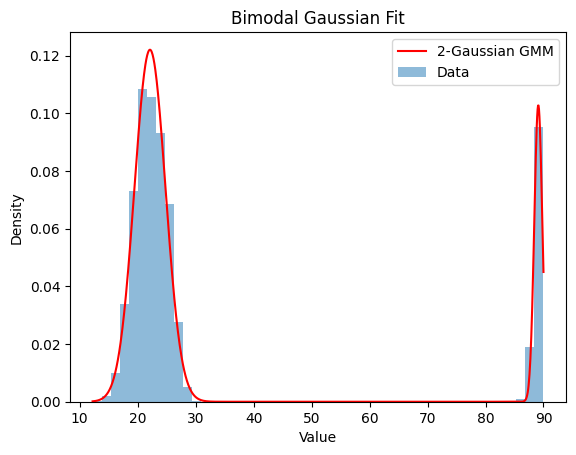

Means: [22.12892866 89.10609453]
Standard Deviations: [2.6830963  0.69479584]


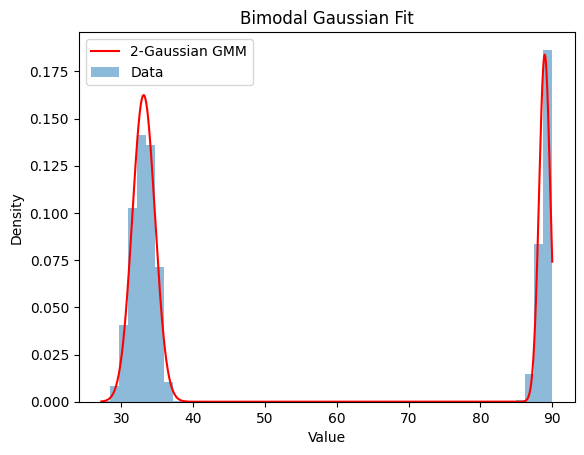

Means: [33.12626513 88.95301163]
Standard Deviations: [1.57653742 0.77677449]


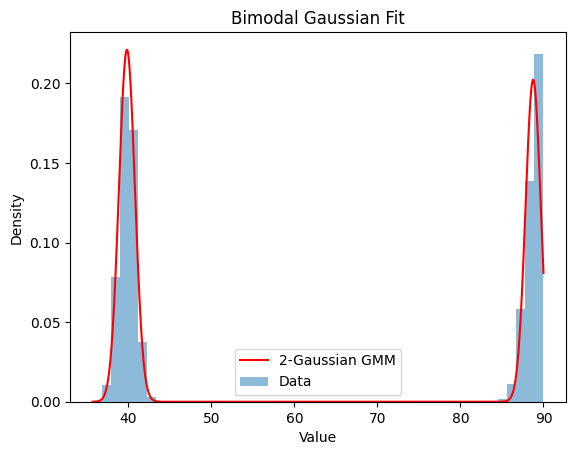

Means: [88.75636877 39.81505993]
Standard Deviations: [0.9179016  0.96390299]


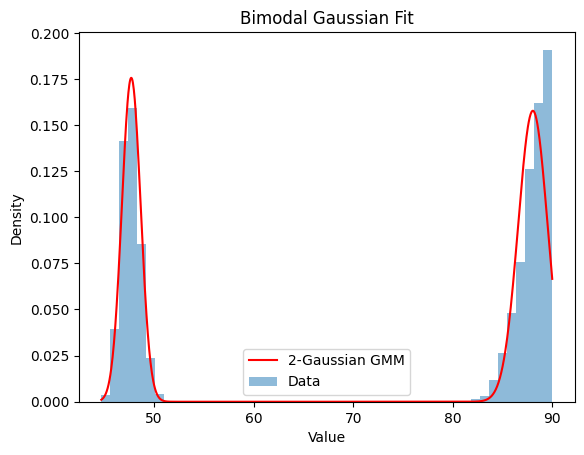

Means: [47.71335424 88.05510478]
Standard Deviations: [0.9416085  1.48091543]


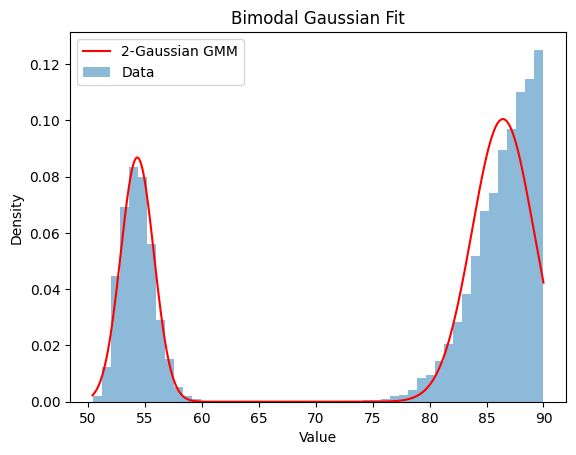

Means: [54.31584494 86.43590244]
Standard Deviations: [1.45763648 2.71030172]


In [14]:
peaks_above_minimum = peaks[peaks>uranus_min_freq]
all_lat, all_stdev = runanalysis(peaks_above_minimum, sromovsky2012_odd, frequency_wind_speed(radius, period), plot=True)

At this stage, it is necessary to manually inspect the plots for the "correct" solution, that is, one within the latitude bounds. The MCMC algorithm my find a comparable solution at ~90 degrees due to the proximity of the wind equation and frequency equations at that latitude. 